In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matpoltlib inline

UsageError: Line magic function `%matpoltlib` not found.


In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

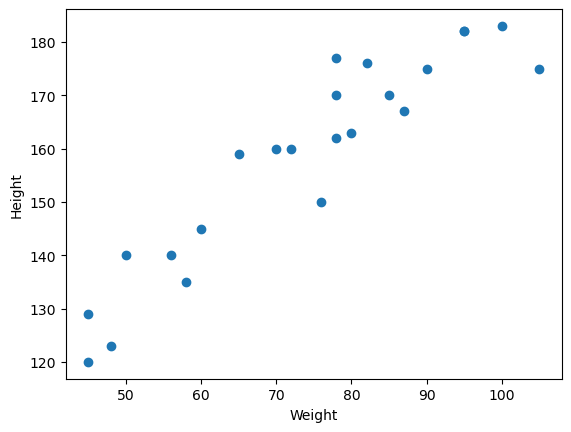

In [5]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")


In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


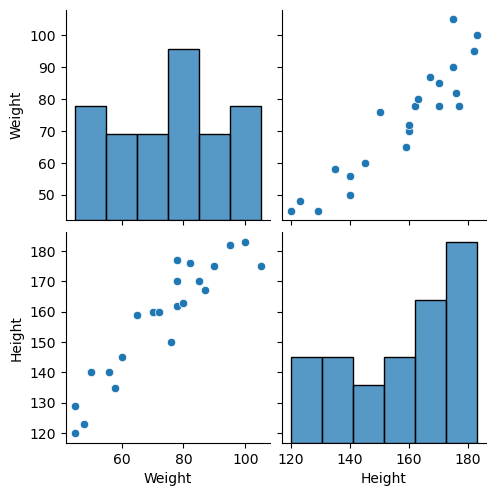

In [7]:
import seaborn as sns
sns.pairplot(df)

In [15]:
## divide the dataset into independent and dependent feature.
## X = df['Weight'] 
X = df[['Weight']] ## the independent feature must be in data frame or 2d array, because of the scikit-learn api that except X as 2d array.
y = df['Height']
## type(X)
##np.array(X).shape

In [ ]:
## splitting into trainingand testing data.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
## test_size=0.20- means 20 percent
## random_state = whenever we run this agian in nay machine,,,we get the same samples.

In [17]:
y_train

12    175
1     135
13    183
5     162
2     123
11    182
20    129
3     145
4     160
18    150
16    140
21    140
22    160
7     175
10    176
14    170
19    167
6     163
Name: Height, dtype: int64

In [18]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

In [19]:
## standardize the dataset using the z-score to have the meadn=0, std_dev=1.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform( X_train)
X_test = scaler.transform(X_test)

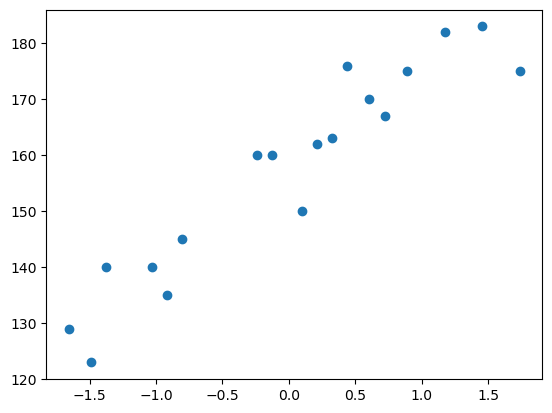

In [20]:
plt.scatter(X_train, y_train)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
regressor = LinearRegression()

In [23]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
type(X_train)

numpy.ndarray

In [ ]:
np.array(X_train).shape


(5, 1)

In [ ]:
np.array(X_test).shape

(5, 1)

In [28]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
print("Coefficient : ", regressor.coef_)
print("Intercept : ", regressor.intercept_)

Coefficient :  [17.03440872]
Intercept :  157.5


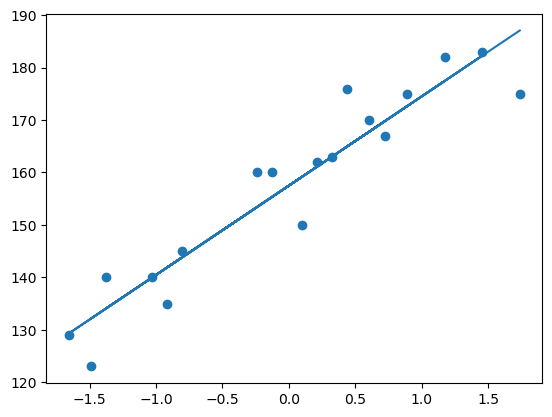

In [32]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regressor.predict(X_train))

In [33]:
y_pred_test = regressor.predict(X_test)

In [34]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

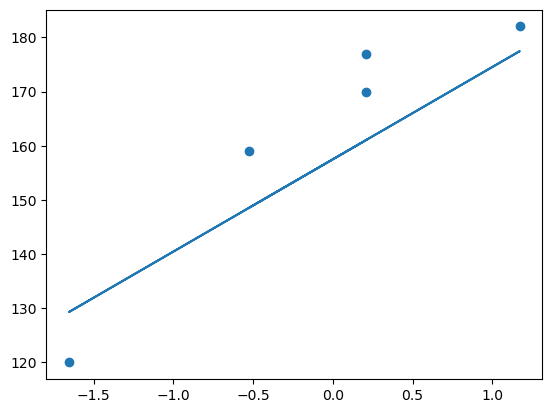

In [38]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test))

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [39]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [40]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)


In [41]:
print(score)

0.776986986042344


In [42]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [ ]:
## predicting new datapoints
regressor.predict(scaler.transform([[75]]))

## note - 75 must be in 2d array
##      - we need to transform using the stabdard scaler.
## regressor.predict(([[75]])) - the wrong value will be prnted.

c:\Users\Siddhant\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([158.19553315])

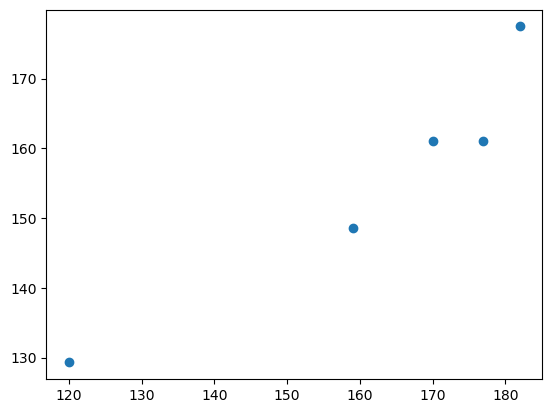

In [44]:
## Assumptions

## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)



In [45]:
## Residuals
residuals=y_test-y_pred_test

residuals



15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

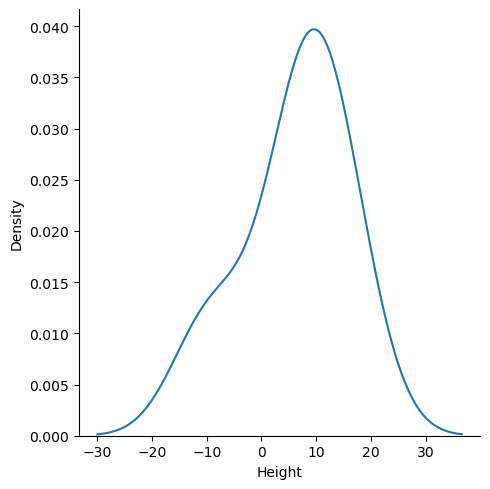

In [46]:
## Plot this residuals 
import seaborn as sns
sns.displot(residuals,kind="kde")



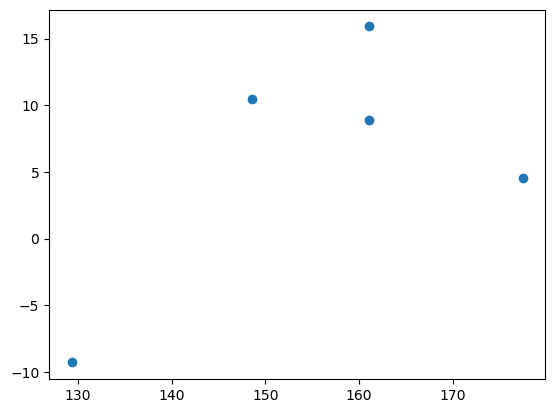

In [47]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)

In [48]:
import statsmodels.api as sm


In [49]:
model = sm.OLS(y_train,  X_train).fit()
predictions = model.predict(X_test)

In [ ]:
print(model.summary())
## see - the coefficent of OLS methos is similar to the coefficient of linear resgression using scilit learn.

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Wed, 08 Jul 2026   Prob (F-statistic):                       0.661
Time:                        20:00:19   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [51]:
regressor.coef_

array([17.03440872])